In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1 - Import Libraries

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set(style="whitegrid")
pd.set_option("display.max_columns", 150)

### 1. Load the Cleaned Dataset

The cleaned CRMLS residential dataset covers January 2025 through May 2026. ClosePrice is used as the target variable.





In [4]:
DATA_PATH = (
    "/content/drive/MyDrive/IDX_Exchange_Su26/data/"
    "crmls_sfr_quality_cleaned_202501_202605.csv"
)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (181185, 97)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,flag_lotsize_extreme,flag_yearbuilt_invalid,flag_daysonmarket_negative,flag_garage_extreme,flag_parking_extreme,flag_latitude_outside_ca,flag_longitude_outside_ca,numeric_strict_issue_flag,numeric_review_flag,close_month
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",0,0,0,0,3288000.0,1097313841,josiechenn@yahoo.com,...,0,0,0,0,0,0,0,0,0,2025-01
1,SierraNorthValley,SierraNorthValley,Wood,1,0,0,0,399000.0,1095538423,ernestsalinasrealtor@gmail.com,...,0,0,0,0,0,0,0,0,0,2025-01
2,OrangeCounty,OrangeCounty,"Carpet,Vinyl",1,0,0,0,660595.0,1095479299,contact.socal@meritagehomes.com,...,0,0,0,0,0,0,0,0,0,2025-01
3,CitrusValley,CitrusValley,NaN,0,0,0,1,1325888.0,1095146807,wjpartida@gmail.com,...,0,0,0,0,0,0,0,0,0,2025-01
4,NorthSanDiegoCounty,NorthSanDiegoCounty,NaN,0,0,0,0,965000.0,1093787744,ebhomesinc@gmail.com,...,0,0,0,0,0,0,0,0,0,2025-01


In [5]:
print("Number of columns:", len(df.columns))
print("\nColumn names:")

print(df.columns.tolist())

Number of columns: 97

Column names:
['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric', 'ListingId', 'BathroomsTotalInteger', 'City', 'TaxYear', 'BuildingAreaTotal', 'BedroomsTotal', 'ContractSta

### 2. Define the Target and Prevent Data Leakage

ClosePrice is the target variable. ListPrice and OriginalListPrice are excluded because they are unavailable for off-market properties and would introduce target leakage.

In [7]:
TARGET = "ClosePrice"

LEAKAGE_COLUMNS = [
    "ListPrice",
    "OriginalListPrice",
    "ClosePrice_to_ListPrice_ratio"
]

if TARGET not in df.columns:
    raise KeyError(f"{TARGET} was not found in the dataset.")

print("Target variable:", TARGET)

print("\nLeakage variables excluded:")
for col in LEAKAGE_COLUMNS:
    if col in df.columns:
        print("-", col)

Target variable: ClosePrice

Leakage variables excluded:
- ListPrice
- OriginalListPrice
- ClosePrice_to_ListPrice_ratio


### 3. Select Baseline Features

In [8]:
numeric_features = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "YearBuilt",
    "GarageSpaces",
    "Stories",
    "Latitude",
    "Longitude"
]

categorical_features = [
    "City",
    "CountyOrParish",
    "PostalCode",
    "ViewYN",
    "WaterfrontYN",
    "BasementYN",
    "PoolPrivateYN",
    "AttachedGarageYN",
    "FireplaceYN",
    "NewConstructionYN"
]

# Keep only columns that exist in the dataset
numeric_features = [
    col for col in numeric_features
    if col in df.columns
]

categorical_features = [
    col for col in categorical_features
    if col in df.columns
]

feature_columns = numeric_features + categorical_features

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTotal number of selected features:", len(feature_columns))

Numerical features:
['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt', 'GarageSpaces', 'Stories', 'Latitude', 'Longitude']

Categorical features:
['City', 'CountyOrParish', 'PostalCode', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']

Total number of selected features: 19


In [10]:
# Verify No Leakage Features Were Selected
selected_leakage = [
    col for col in LEAKAGE_COLUMNS
    if col in feature_columns
]

if selected_leakage:
    raise ValueError(
        f"Leakage variables were included by mistake: {selected_leakage}"
    )

print("Leakage check passed.")
print("ListPrice and OriginalListPrice are not included.")

Leakage check passed.
ListPrice and OriginalListPrice are not included.


In [11]:
# Prepare the Month Variable
if "close_month" not in df.columns:
    raise KeyError("The column 'close_month' was not found.")

df["close_month"] = df["close_month"].astype(str)

print("Available months:")
print(sorted(df["close_month"].dropna().unique()))

Available months:
['2025-01', '2025-02', '2025-03', '2025-04', '2025-05', '2025-06', '2025-07', '2025-08', '2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03', '2026-04', '2026-05']


### 4. Create the Chronological Train/Test Split

In [12]:
test_month = sorted(df["close_month"].dropna().unique())[-1]

train_df = df[df["close_month"] < test_month].copy()
test_df = df[df["close_month"] == test_month].copy()

print("Training period:")
print(train_df["close_month"].min(), "to", train_df["close_month"].max())

print("\nTest month:")
print(test_month)

print("\nTraining observations:", len(train_df))
print("Test observations:", len(test_df))

Training period:
2025-01 to 2026-04

Test month:
2026-05

Training observations: 169173
Test observations: 12012


### 5. Create X and y

In [13]:
X_train = train_df[feature_columns].copy()
y_train = train_df[TARGET].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[TARGET].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (169173, 19)
y_train shape: (169173,)
X_test shape: (12012, 19)
y_test shape: (12012,)


In [14]:
# Ensure Correct Data Types
for col in numeric_features:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

for col in categorical_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

y_train = pd.to_numeric(y_train, errors="coerce")
y_test = pd.to_numeric(y_test, errors="coerce")

In [15]:
# Remove Any Remaining Invalid Rows
train_valid = y_train.notna()
test_valid = y_test.notna()

X_train = X_train.loc[train_valid].copy()
y_train = y_train.loc[train_valid].copy()

X_test = X_test.loc[test_valid].copy()
y_test = y_test.loc[test_valid].copy()

print("Training observations after target check:", len(X_train))
print("Test observations after target check:", len(X_test))

Training observations after target check: 169173
Test observations after target check: 12012


### 6. Build the Preprocessing and Linear Regression Pipeline

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

baseline_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LivingArea',
                                                   'BedroomsTotal',
                                                   'BathroomsTotalInteger',
                                                   'LotSizeSquareFeet',
                                                   'YearBuilt', 'GarageSpaces',
                                                   'Stories', 'Latitude',
                                                   'Longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['City', 'CountyOrParish',
                                                   'PostalCode', 'ViewYN',
                                                   'WaterfrontYN', 'BasementYN',
                                                   'PoolPrivateYN',
                                                   'AttachedGarageYN',
                                                   'FireplaceYN',
                                                   'NewConstructionYN'])])),
                ('model', LinearRegression())])

### 7. Train the Linear Regression Model

In [20]:
print(X_train.isna().sum()[X_train.isna().sum() > 0])

LivingArea                  90
BathroomsTotalInteger       20
LotSizeSquareFeet         2962
YearBuilt                  113
GarageSpaces              6632
Stories                  18184
dtype: int64


In [21]:
baseline_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### 8. Make Predictions

In [22]:
y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

print("Predictions generated.")

Predictions generated.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### 9. Evaluate Using R²

In [23]:
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Linear Regression Baseline Results")
print("-" * 40)
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²:     {test_r2:.4f}")

Linear Regression Baseline Results
----------------------------------------
Training R²: 0.6835
Test R²:     0.7369


### 10. Record the Baseline Results

In [24]:
baseline_results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "Training_Start_Month": [train_df["close_month"].min()],
    "Training_End_Month": [train_df["close_month"].max()],
    "Test_Month": [test_month],
    "Number_of_Training_Observations": [len(X_train)],
    "Number_of_Test_Observations": [len(X_test)],
    "Number_of_Features": [len(feature_columns)],
    "Training_R2": [train_r2],
    "Test_R2": [test_r2]
})

baseline_results

,Model,Training_Start_Month,Training_End_Month,Test_Month,Number_of_Training_Observations,Number_of_Test_Observations,Number_of_Features,Training_R2,Test_R2
0,Linear Regression,2025-01,2026-04,2026-05,169173,12012,19,0.683532,0.736904


### 11. Plot Actual vs Predicted ClosePrice

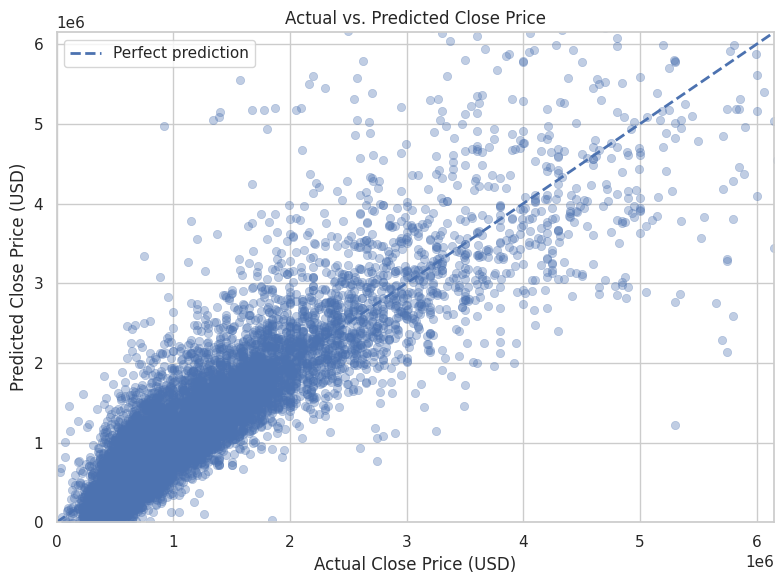

In [25]:
plot_df = pd.DataFrame({
    "ActualClosePrice": y_test.values,
    "PredictedClosePrice": y_test_pred
})

plot_limit = max(
    plot_df["ActualClosePrice"].quantile(0.99),
    plot_df["PredictedClosePrice"].quantile(0.99)
)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=plot_df,
    x="ActualClosePrice",
    y="PredictedClosePrice",
    alpha=0.35,
    edgecolor=None
)

plt.plot(
    [0, plot_limit],
    [0, plot_limit],
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

plt.xlim(0, plot_limit)
plt.ylim(0, plot_limit)

plt.title("Actual vs. Predicted Close Price")
plt.xlabel("Actual Close Price (USD)")
plt.ylabel("Predicted Close Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# Save results
RESULTS_PATH = (
    "/content/drive/MyDrive/IDX_Exchange_Su26/data/"
    "week4_linear_regression_baseline_results.csv"
)

baseline_results.to_csv(RESULTS_PATH, index=False)

print("Baseline results saved to:")
print(RESULTS_PATH)

Baseline results saved to:
/content/drive/MyDrive/IDX_Exchange_Su26/data/week4_linear_regression_baseline_results.csv


In [27]:
# Final Summary
print("WEEK 4 BASELINE MODEL SUMMARY")
print("=" * 50)

print("Model: Linear Regression")
print(f"Training period: {train_df['close_month'].min()} to {train_df['close_month'].max()}")
print(f"Test month: {test_month}")
print(f"Training observations: {len(X_train):,}")
print(f"Test observations: {len(X_test):,}")
print(f"Selected raw features: {len(feature_columns)}")
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")

print("\nListPrice and OriginalListPrice were excluded to prevent data leakage.")

WEEK 4 BASELINE MODEL SUMMARY
Model: Linear Regression
Training period: 2025-01 to 2026-04
Test month: 2026-05
Training observations: 169,173
Test observations: 12,012
Selected raw features: 19
Training R²: 0.6835
Test R²: 0.7369

ListPrice and OriginalListPrice were excluded to prevent data leakage.


## Conclusion

A Linear Regression model was trained as the initial baseline for predicting ClosePrice. The model used property characteristics and location-related features that are available for both on-market and off-market properties.

The training set included all available transactions before the most recent month, while the most recent month was reserved as the test set. The model achieved a test R² of **0.7369**.

ListPrice, OriginalListPrice, and ClosePrice-to-ListPrice ratio were excluded because they would introduce target leakage and would not be available for off-market properties. This Linear Regression model will serve as the benchmark for comparison with more flexible models in later weeks.